/tmp/ipykernel_20298/1373769685.py:58: RuntimeWarning: invalid value encountered in divide
  dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255
/tmp/ipykernel_20298/1373769685.py:58: RuntimeWarning: invalid value encountered in cast
  dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255


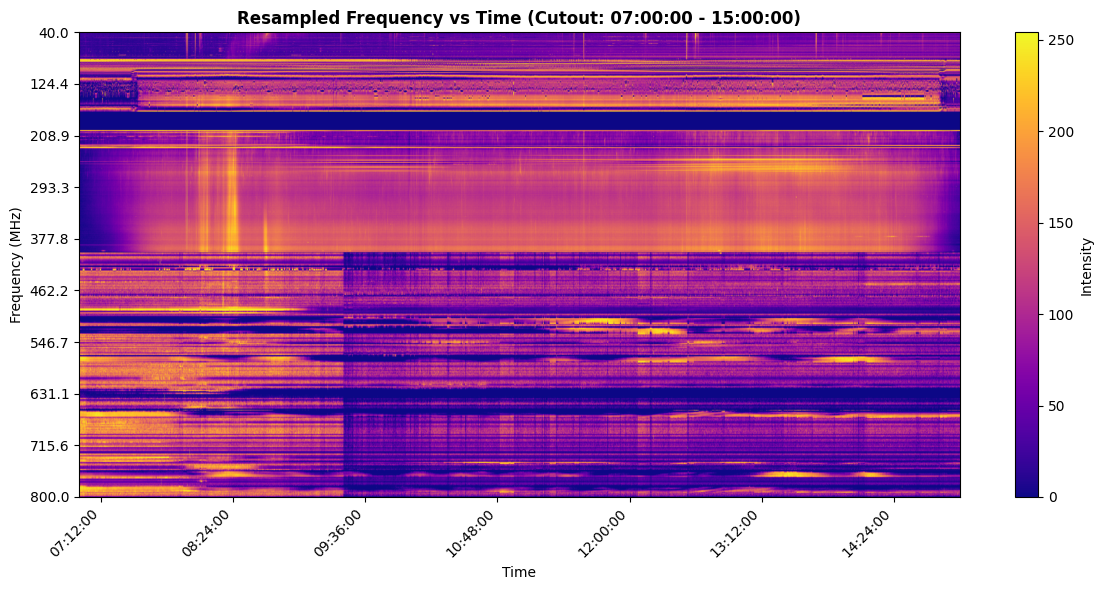

In [1]:
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits as fits
import os
import scipy.ndimage
#fname ="/net/lyot/scratch3/vocks/OSRA/1998/CD_232/980820_232.roh"
#fname ="/net/lyot/scratch3/vocks/OSRA/2003/CD_301/031028_301.roh"
fname ="/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh" 
# Define the frequency arrays
f1 = 800.0 - np.array(range(256)) * 400.0 / 256.0
f2 = 400.0 - np.array(range(256)) * 200.0 / 255.0
f3 = 170.0 - np.array(range(256)) * 70.0 / 256.0
f4 = 100.0 - np.array(range(256)) * 60.0 / 255.0
f_fits = np.concatenate((f1, f2, f3, f4))

# Simulate file size and stats
file_stats = os.stat(fname)
a1 = int(file_stats.st_size / 1040 + 0.5)

# Create a dummy start time
dummy_start = np.datetime64('2025-02-01T15:23:15.00')
t_fits = dummy_start + np.linspace(0, 1, a1).astype('timedelta64[D]')

# Initialize the spectrum array
dyspec = np.zeros((a1, 1024), dtype=np.ubyte)

# Simulate reading the file
file = open(fname, "rb")
for i in range(a1):
    data_chunk = file.read(1040)
    np_data_chunk = np.frombuffer(data_chunk, dtype=np.uint8)
    year = int(np_data_chunk[0] / 16) * 10 + (np_data_chunk[0] & 15)
    if year > 50:
        year = year + 1900
    else:
        year = year + 2000

    # Extract time information
    month = int(np_data_chunk[1] / 16) * 10 + (np_data_chunk[1] & 15)
    day = int(np_data_chunk[2] / 16) * 10 + (np_data_chunk[2] & 15)
    hour = int(np_data_chunk[3] / 16) * 10 + (np_data_chunk[3] & 15)
    minute = int(np_data_chunk[4] / 16) * 10 + (np_data_chunk[4] & 15)
    second = int(np_data_chunk[5] / 16) * 10 + (np_data_chunk[5] & 15)
    microsecond = 100000 * np_data_chunk[6]

    t_fits[i] = datetime.datetime(year, month, day, hour, minute, second, microsecond)
    dyspec[i, :] = np_data_chunk[16:]  # Insert frequency information

file.close()

# Normalize the data
dyspec_norm = np.zeros((a1, 1024), dtype=np.ubyte)
for j in range(1024):
    Imax = np.amax(dyspec[:, j])
    Imin = np.amin(dyspec[:, j])
    dyspec_norm[:, j] = (dyspec[:, j] - Imin) / (Imax - Imin) * 255

# Transpose the normalized data 
dyspec_norm = dyspec_norm.T

# Define the time range for the cutout
start_time = np.datetime64('2003-10-27T07:00:00.000')
end_time = np.datetime64('2003-10-27T15:00:00.000')

# Create a boolean mask for the desired time range
time_mask = (t_fits >= start_time) & (t_fits <= end_time)

# Extract the cutout arrays
t_fits_cutout = t_fits[time_mask]
dyspec_norm_cutout = dyspec_norm[:, time_mask]

# Convert cutout time for plotting
t_plot_cutout = mdates.date2num(t_fits_cutout)


# Define new frequency range (800 MHz to 40 MHz)
new_frequencies = np.linspace(800, 40, 3801)
target_steps = 5000


# Extract the cutout arrays
t_fits_cutout = t_fits[time_mask]
dyspec_cutout = dyspec[time_mask, :]  # Use original dyspec for resampling
a2 = len(t_fits_cutout)  # Update a2 to the cutout length

# Initialize resampled data for the cutout
new_dyspec = np.zeros((target_steps, len(new_frequencies)), dtype=np.uint8)

# Resample each frequency segment using scipy.ndimage.zoom
temp_array = dyspec_cutout[:, 0:256]
zoomed_array = scipy.ndimage.zoom(temp_array, (target_steps/a2, 2000/256))
new_dyspec[:, 0:2000] = zoomed_array

temp_array = dyspec_cutout[:, 256:512]
zoomed_array = scipy.ndimage.zoom(temp_array, (target_steps/a2, 1001/256))
new_dyspec[:, 2000:3001] = zoomed_array

temp_array = dyspec_cutout[:, 512:768]
zoomed_array = scipy.ndimage.zoom(temp_array, (target_steps/a2, 350/256))
new_dyspec[:, 3150:3500] = zoomed_array

temp_array = dyspec_cutout[:, 768:1024]
zoomed_array = scipy.ndimage.zoom(temp_array, (target_steps/a2, 301/256))
new_dyspec[:, 3500:3801] = zoomed_array

# Normalize new data
new_dyspec_norm = ((new_dyspec - new_dyspec.min(axis=0)) / 
                   (new_dyspec.ptp(axis=0) + 1e-6) * 255).astype(np.uint8)

# Convert cutout time for plotting
t_plot_cutout = mdates.date2num(t_fits_cutout)

# Plot the resampled cutout
plt.figure(figsize=(12, 6))
plot_array = new_dyspec_norm.T
plot_array = np.flip(plot_array, axis=0)
im = plt.imshow(
    plot_array, aspect='auto', cmap='plasma',
    extent=[t_plot_cutout[0], t_plot_cutout[-1], new_frequencies[0], new_frequencies[-1]]
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha='right')
plt.xlabel('Time')
plt.ylabel('Frequency (MHz)')
plt.title('Resampled Frequency vs Time (Cutout: 07:00:00 - 15:00:00)', fontweight="bold")
plt.colorbar(im, label='Intensity')
plt.yticks(np.linspace(new_frequencies[0], new_frequencies[-1], 10))
plt.tight_layout()
plt.show()